# NASA IMS Bearing Dataset — Data Loading & Exploration
This notebook loads the raw IMS bearing vibration data from Test 1,
parses timestamps from filenames, and builds a unified DataFrame for analysis.

**Dataset:** 4 bearings running at 2000 RPM until failure.  
**Sampling rate:** 20,480 Hz  
**Each file:** 1 second of data = 20,480 rows × 4 columns (one per bearing)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Plot styling
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = Path("../data/1st_test")

In [2]:
def load_ims_dataset(data_dir):
    files = sorted(data_dir.iterdir())
    dfs = []

    for file in files:
        if not file.is_file():
            continue

        df = pd.read_csv(
            file,
            sep="\t",
            header=None,
            names=["bearing_1", "bearing_2", "bearing_3", "bearing_4"]
        )

        parts = file.name.split(".")
        timestamp = pd.Timestamp(
            year=int(parts[0]), month=int(parts[1]), day=int(parts[2]),
            hour=int(parts[3]), minute=int(parts[4]), second=int(parts[5])
        )

        df["timestamp"] = timestamp
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

df = load_ims_dataset(DATA_DIR)
print(f"Dataset shape: {df.shape}")
print(f"Time range: {df['timestamp'].min()} → {df['timestamp'].max()}")
df.head()

Dataset shape: (44154880, 5)
Time range: 2003-10-22 12:06:24 → 2003-11-25 23:39:56


,bearing_1,bearing_2,bearing_3,bearing_4,timestamp
0,-0.105,-0.134,-0.129,-0.142,2003-10-22 12:06:24
1,-0.049,0.029,-0.115,-0.122,2003-10-22 12:06:24
2,-0.005,-0.007,-0.171,-0.071,2003-10-22 12:06:24
3,-0.100,-0.115,-0.112,-0.078,2003-10-22 12:06:24
4,-0.151,-0.205,-0.063,-0.066,2003-10-22 12:06:24


## Sanity Checks
Verify there are no missing values and the data looks reasonable.

In [8]:
print("Missing values:\n", df.isnull().sum())
print("\nBasic statistics:")

stats = df[["bearing_1", "bearing_2", "bearing_3", "bearing_4"]].describe()

# Format count row as int, everything else as 5 decimal float
formatted = stats.copy().astype(str)
for col in stats.columns:
    for row in stats.index:
        if row == "count":
            formatted.loc[row, col] = str(int(stats.loc[row, col]))
        else:
            formatted.loc[row, col] = f"{stats.loc[row, col]:.5f}"

print(formatted.to_string())

Missing values:
 bearing_1    0
bearing_2    0
bearing_3    0
bearing_4    0
timestamp    0
dtype: int64

Basic statistics:
      bearing_1 bearing_2 bearing_3 bearing_4
count  44154880  44154880  44154880  44154880
mean   -0.11276  -0.11288  -0.11285  -0.11272
std     0.11811   0.12157   0.09634   0.09894
min    -5.00000  -5.00000  -3.97500  -3.80100
25%    -0.18600  -0.18800  -0.16600  -0.16800
50%    -0.11200  -0.11200  -0.11200  -0.11200
75%    -0.03900  -0.03700  -0.06100  -0.05600
max     4.99800   4.72400   3.93800   3.59600


## Raw Signal Visualization
Plot a single second of raw vibration data to understand what we're working with.

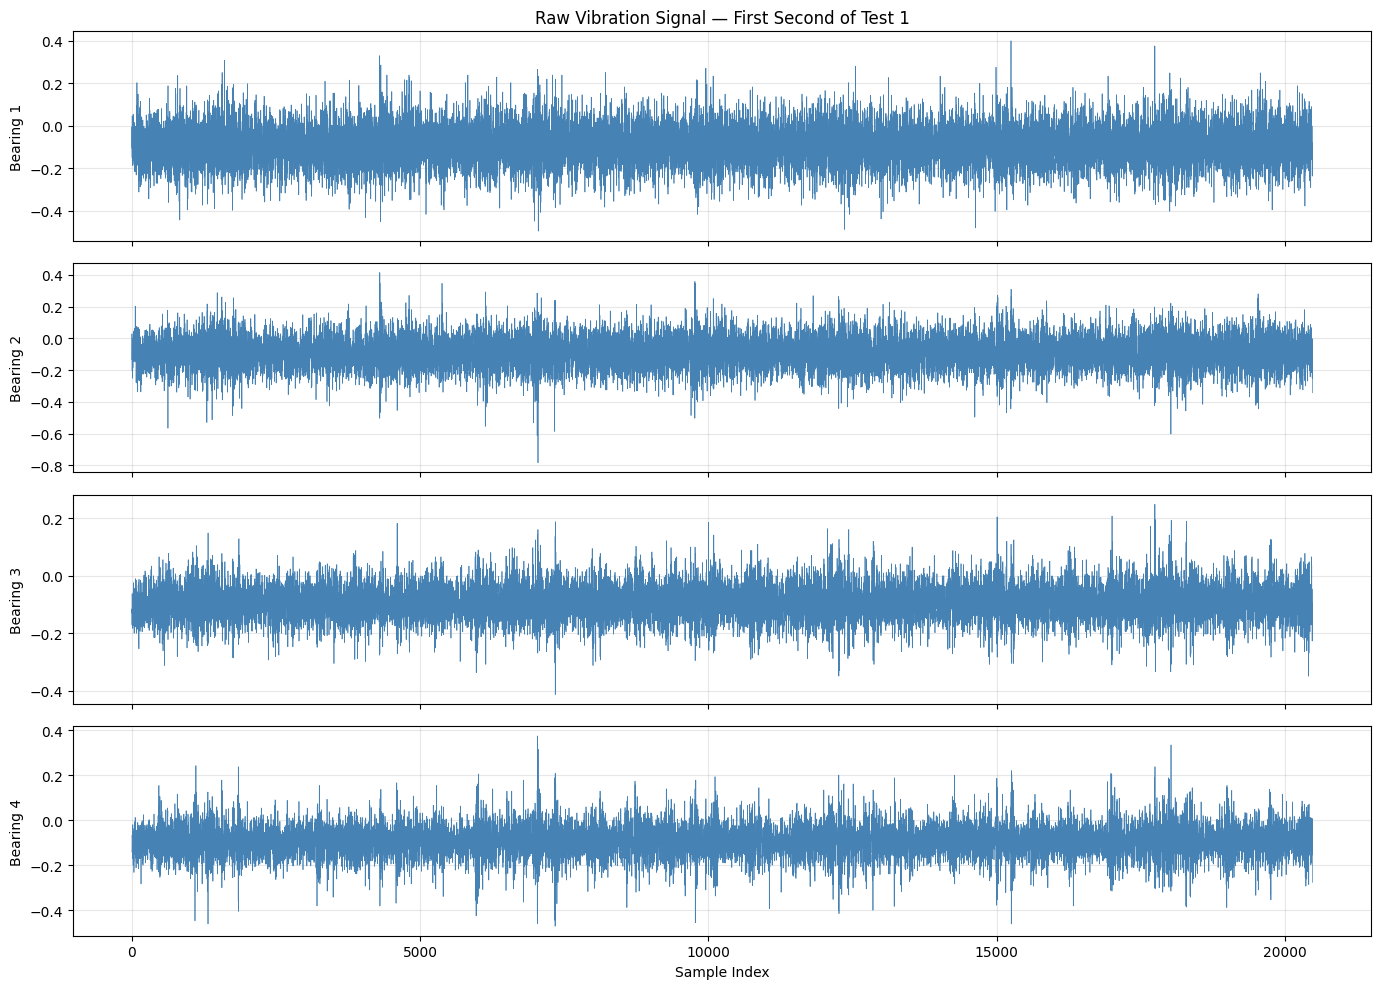

In [4]:
# Grab the first file's worth of data (one second)
sample = df[df["timestamp"] == df["timestamp"].min()]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for i, bearing in enumerate(["bearing_1", "bearing_2", "bearing_3", "bearing_4"]):
    axes[i].plot(sample[bearing].values, linewidth=0.5, color="steelblue")
    axes[i].set_ylabel(bearing.replace("_", " ").title())

axes[0].set_title("Raw Vibration Signal — First Second of Test 1")
axes[-1].set_xlabel("Sample Index")
plt.tight_layout()
plt.savefig("../outputs/figures/01_raw_signal.png", dpi=150)
plt.show()